## 1. Setup & Imports

Prompt: I'm going to work with a CSV dataset for data exploration, visualization, and clustering. Import everything I need for data manipulation, statistical summaries, static and interactive charts, and machine learning preprocessing.

In [3]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

# Statistical summaries
import scipy.stats as stats

# Static visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Display settings for pandas
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

## 2. Load & Explore the Dataset

In [4]:
SELECT *
FROM patient_insurance_dataset.csv

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18 00:00:00+00:00,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12 00:00:00+00:00,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16 00:00:00+00:00,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09 00:00:00+00:00,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07 00:00:00+00:00,319,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,P11995,37,Male,IL,Springfield,195,109,28.7,Medicaid,None,0,4,4581.0,2025-09-20 00:00:00+00:00,122,1
1996,P11996,32,Female,NY,Rochester,151,94,41.2,Private,None,0,1,329.0,2025-08-23 00:00:00+00:00,150,1
1997,P11997,50,Female,NC,Unknown,149,115,51.8,Private,Anxiety,1,8,4942.5,2025-05-23 00:00:00+00:00,242,1
1998,P11998,74,Female,NC,Unknown,165,97,35.6,Medicare,Heart Disease,3,7,4700.0,2025-07-09 00:00:00+00:00,195,1


Prompt: Show shape, data types and a statistical summary of the patients_df DataFrame. Also show the value counts for all categorical columns. Add only code block. Do not add markdown cells.



In [5]:
# Show shape
patients_df.shape

# Show data types
patients_df.dtypes

# Show statistical summary
patients_df.describe(include='all')

# Show value counts for all categorical columns
categorical_cols = patients_df.select_dtypes(include=['object', 'category']).columns
{col: patients_df[col].value_counts() for col in categorical_cols}

{'PatientID': PatientID
 P11983    1
 P11982    1
 P11981    1
 P11980    1
 P11979    1
          ..
 P10004    1
 P10003    1
 P10002    1
 P10001    1
 P10000    1
 Name: count, Length: 2000, dtype: int64,
 'Gender': Gender
 Female    1001
 Male       999
 Name: count, dtype: int64,
 'State': State
 NC    213
 GA    211
 CA    209
 OH    208
 IL    205
 NY    196
 TX    195
 MI    191
 PA    189
 FL    183
 Name: count, dtype: int64,
 'City': City
 Unknown          1012
 Springfield        80
 Chicago            72
 Los Angeles        57
 San Francisco      54
 Naperville         53
 Buffalo            53
 Houston            52
 Tampa              51
 Dallas             50
 San Diego          50
 New York           49
 Sacramento         48
 Orlando            47
 Albany             47
 San Antonio        47
 Rochester          47
 Austin             46
 Jacksonville       43
 Miami              42
 Name: count, dtype: int64,
 'Insurance_Type': Insurance_Type
 Medicare    906
 Priva

## 3. Data Cleaning

One of the things necessary is to determine whether you have missing values. Handling missing values is always difficult. If only a few observations are missing, they can be excluded. If there is a significant number of missing values, several options are available depending on the type of missing value.

But here's the catch: missing values don't always show up as `NaN`. Sometimes they hide as strings like `"Unknown"`, `"None"`, `"N/A"`, or even blank spaces. The AI or even Pandas won't flag these automatically. You need to check for them yourself.

Prompt: Check for missing values in the patients_df DataFrame.

In [6]:
patients_df.isnull().sum()

PatientID                 0
Age                       0
Gender                    0
State                     0
City                      0
Height_cm                 0
Weight_kg                 0
BMI                       0
Insurance_Type            0
Primary_Condition         0
Num_Chronic_Conditions    0
Annual_Visits             0
Avg_Billing_Amount        0
Last_Visit_Date           0
Days_Since_Last_Visit     0
Preventive_Care_Flag      0
dtype: int64

The AI tells us that the dataset doesn't have missing values. Is that correct?

You should re-check the actual values that you saw when we count the values in each column. Sometimes "missing" data hides behind placeholder strings. 

If you look at the **City** column there are values recorded as "Unknown". Also, the **Primary condition** has "None" as a value. Pandas didn't flag these as missing because technically they're valid strings. But "Unknown" is not a real city. It's a disguised missing value.

This is a very common problem in real-world data, especially in healthcare. Missing data is sometimes filled with placeholder text like "Unknown", "None", "Not Specified", or "N/A" instead of leaving them as actual null values.

**The AI missed this.** It only checked for `NaN` values.

Prompt: The values "None" and "Unknown" should be considered missing values. Check again for missing values in all the columns of df DataFrame. Save the data with values converted to nan in a variable called patients_nan_df

In [7]:
import numpy as np

# Replace "None" and "Unknown" with np.nan in all columns
patients_nan_df = patients_df.replace(["None", "Unknown"], np.nan)

# Check for missing values in all columns
patients_nan_df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
State                        0
City                      1012
Height_cm                    0
Weight_kg                    0
BMI                          0
Insurance_Type               0
Primary_Condition          495
Num_Chronic_Conditions       0
Annual_Visits                0
Avg_Billing_Amount           0
Last_Visit_Date              0
Days_Since_Last_Visit        0
Preventive_Care_Flag         0
dtype: int64

Now you can see the true picture of missing data. The City column has ~50% missing, which is very high to impute reliably.

Also, you can observe that the Primary Condition for 495 patients is missing. On a deeper analysis, you can see that when the primary condition is present it has a disease or health condition associated.

Prompt: The DataFrame patients_nan_df has 495 missing values in Primary_Condition. When the condition is present, it always names a disease. So missing = no condition. Fill them with 'No Condition', save the new DataFrame in a varible called patients_nan_replaced and **verify.**

In [8]:
patients_nan_df['Primary_Condition']=patients_nan_df['Primary_Condition'].fillna('No Condition')
patients_nan_replaced= patients_nan_df
patients_nan_replaced.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
State                        0
City                      1012
Height_cm                    0
Weight_kg                    0
BMI                          0
Insurance_Type               0
Primary_Condition            0
Num_Chronic_Conditions       0
Annual_Visits                0
Avg_Billing_Amount           0
Last_Visit_Date              0
Days_Since_Last_Visit        0
Preventive_Care_Flag         0
dtype: int64

## 4. Exploratory Data Analysis


It is important you should get descriptive statistics and distribution of each variable of interest. Looking into distributions and descriptive statistics allows us to understand our patient population and determine if we need to perform any data transformation before clustering.

- For numerical variables, you need visualizations that helps you understand the spread and potential outliers in each feature. Also, you need to understand correlations.

- For categorical variables, you need counts that gives you insight into the distribution of these categories in the dataset.

Prompt: Create a grid of histograms with KDE curves for all numeric columns, count plots for the categorical columns Gender, Insurance_Type, and Primary_Condition. Use the patients_nan_replaced DataFrame. Use seaborn with the Set2 palette. Do not add markdown cells.

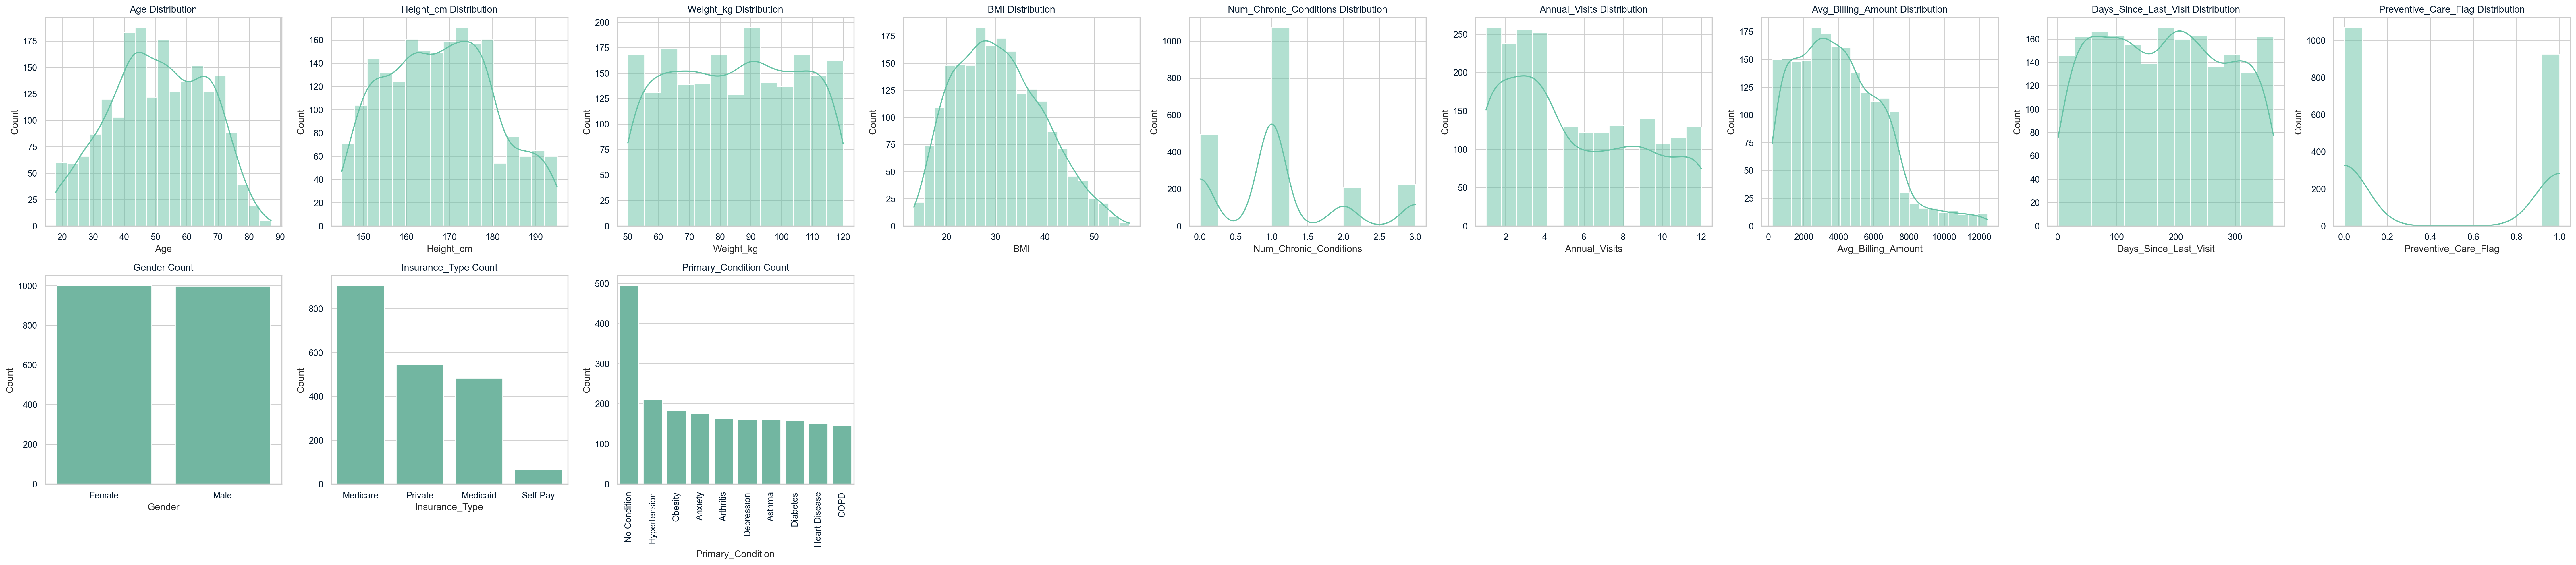

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set seaborn style and palette
sns.set(style="whitegrid", palette="Set2")

# Identify numeric and categorical columns
numeric_cols = patients_nan_replaced.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Plot numeric columns: histograms with KDE
n_num = len(numeric_cols)
n_cat = len(categorical_cols)

# Set up the grid: 2 rows, one for numeric, one for categorical
fig, axes = plt.subplots(nrows=2, ncols=max(n_num, n_cat), figsize=(5*max(n_num, n_cat), 10))

# Plot numeric columns
for i, col in enumerate(numeric_cols):
    ax = axes[0, i] if n_num > 1 else axes[0]
    sns.histplot(patients_nan_replaced[col], kde=True, ax=ax)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Hide unused numeric axes if any
for j in range(i+1, max(n_num, n_cat)):
    axes[0, j].set_visible(False)

# Plot categorical columns: count plots
for i, col in enumerate(categorical_cols):
    ax = axes[1, i] if n_cat > 1 else axes[1]
    sns.countplot(data=patients_nan_replaced, x=col, ax=ax, order=patients_nan_replaced[col].value_counts().index)
    ax.set_title(f'{col} Count')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    if col == 'Primary_Condition':
        ax.tick_params(axis='x', rotation=90)

# Hide unused categorical axes if any
for j in range(i+1, max(n_num, n_cat)):
    axes[1, j].set_visible(False)

plt.tight_layout()
plt.show()

Prompt: Create a correlation heatmap for the numeric columns in the DataFrame patients_nan_replaced. Use seaborn with coolwarm palette. Annotate the heatmap with correlation values and show only the lower triangle. Do not add markdown cells.

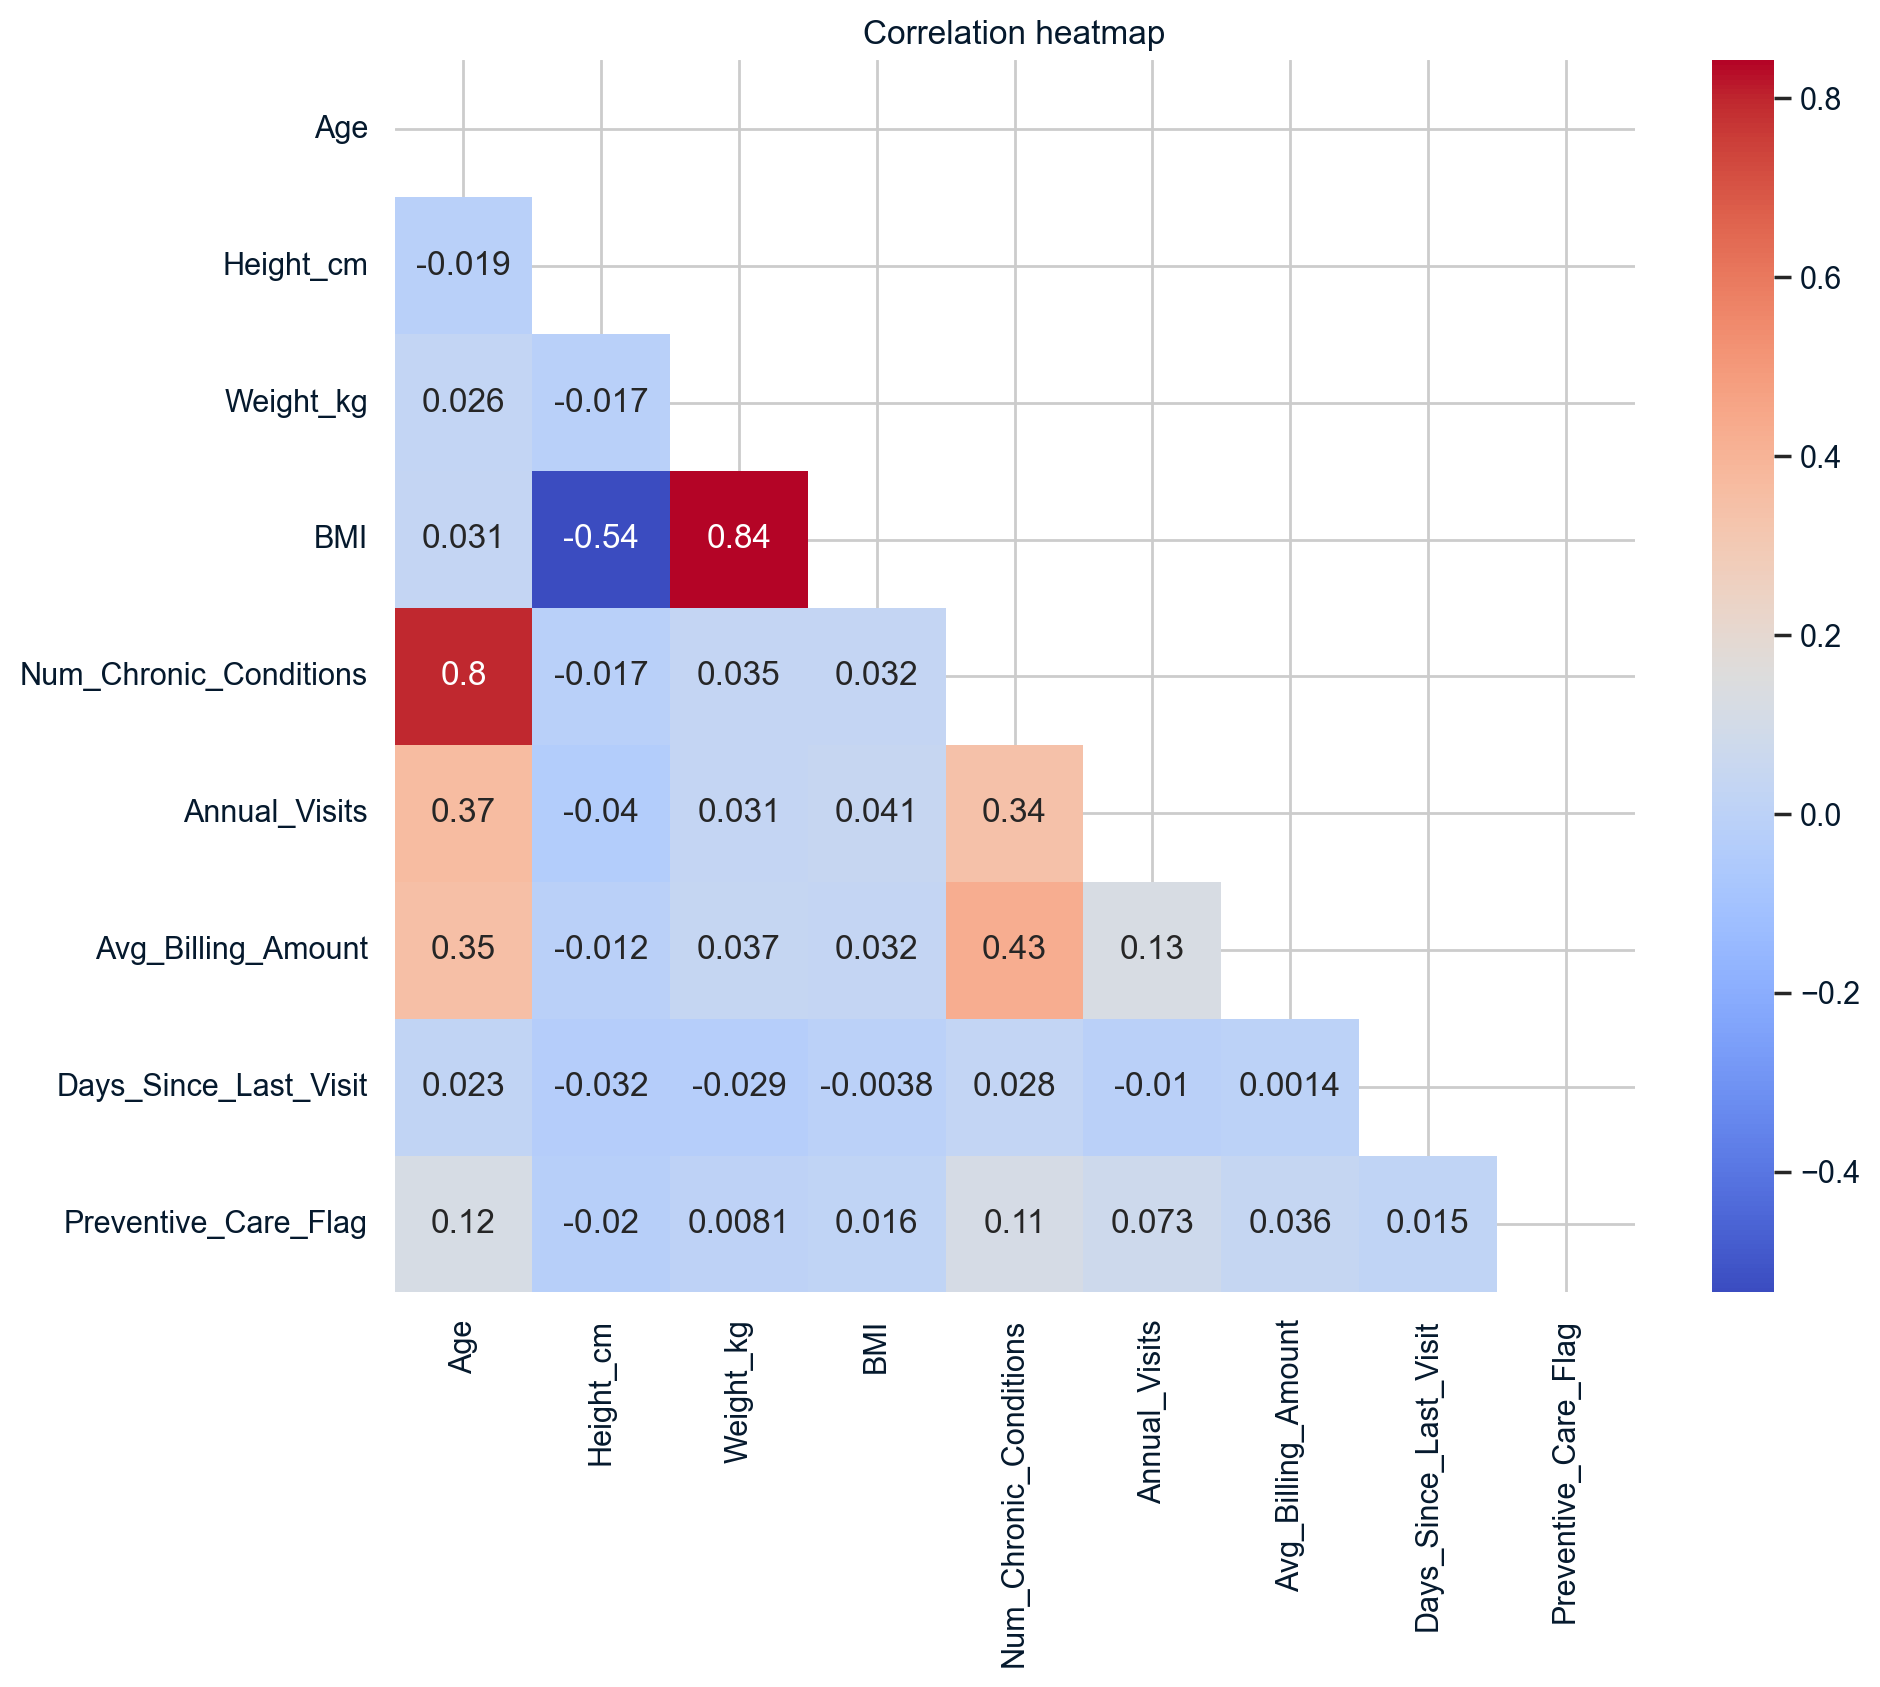

In [16]:
corr_matrix= patients_nan_replaced.corr(numeric_only=True)
mask=np.triu(np.ones_like(corr_matrix,dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,mask=mask, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

The correlation heatmap shows how numeric features relate to each other. This helps you understand which features move together and whether any are redundant. Highly correlated features can bias clustering by effectively double-counting the same information.

The correlation heatmap reveals important relationships:

- **Age and Num_Chronic_Conditions** are strongly correlated (r = 0.80). Older patients tend to accumulate more chronic conditions.
- **Weight_kg and BMI** are strongly correlated (r = 0.84), and **Height_cm and BMI** show moderate negative correlation (r = -0.54). Since BMI is derived from height and weight, we will keep only BMI to avoid redundancy.
- **Age, Num_Chronic_Conditions, Annual_Visits, and Avg_Billing_Amount** form a cluster of moderate positive correlations (r = 0.34-0.43). Older, sicker patients visit more and cost more.
- **Days_Since_Last_Visit** shows near-zero correlation with everything else, it captures an independent dimension of patient behavior.

## 5. Clustering

Let's ask the AI to cluster our patients. A natural first instinct, and what most AI assistants will suggest, is **K-Means**.

Prompt: From the dataframe patients_nan_replaced select the numerical variables: Age, BMI, Num_Chronic_Conditions, Annual_Visits, Avg_Billing_Amount, Days_Since_Last_Visit and the categorical variables: Gender, Insurance_Type, and Primary_Condition. Save this new DataFrame in a variable called final_patients_df. 

In [18]:
final_patients_df=patients_nan_replaced[['Age','BMI','Num_Chronic_Conditions','Annual_Visits','Avg_Billing_Amount','Days_Since_Last_Visit','Gender','Insurance_Type','Primary_Condition']]

Prompt: Using final_patients_df, cluster these patients into meaningful segments. Use the most suitable method to choose k and show the process using a graph. Set sparse_output to False in OneHotEncoder.

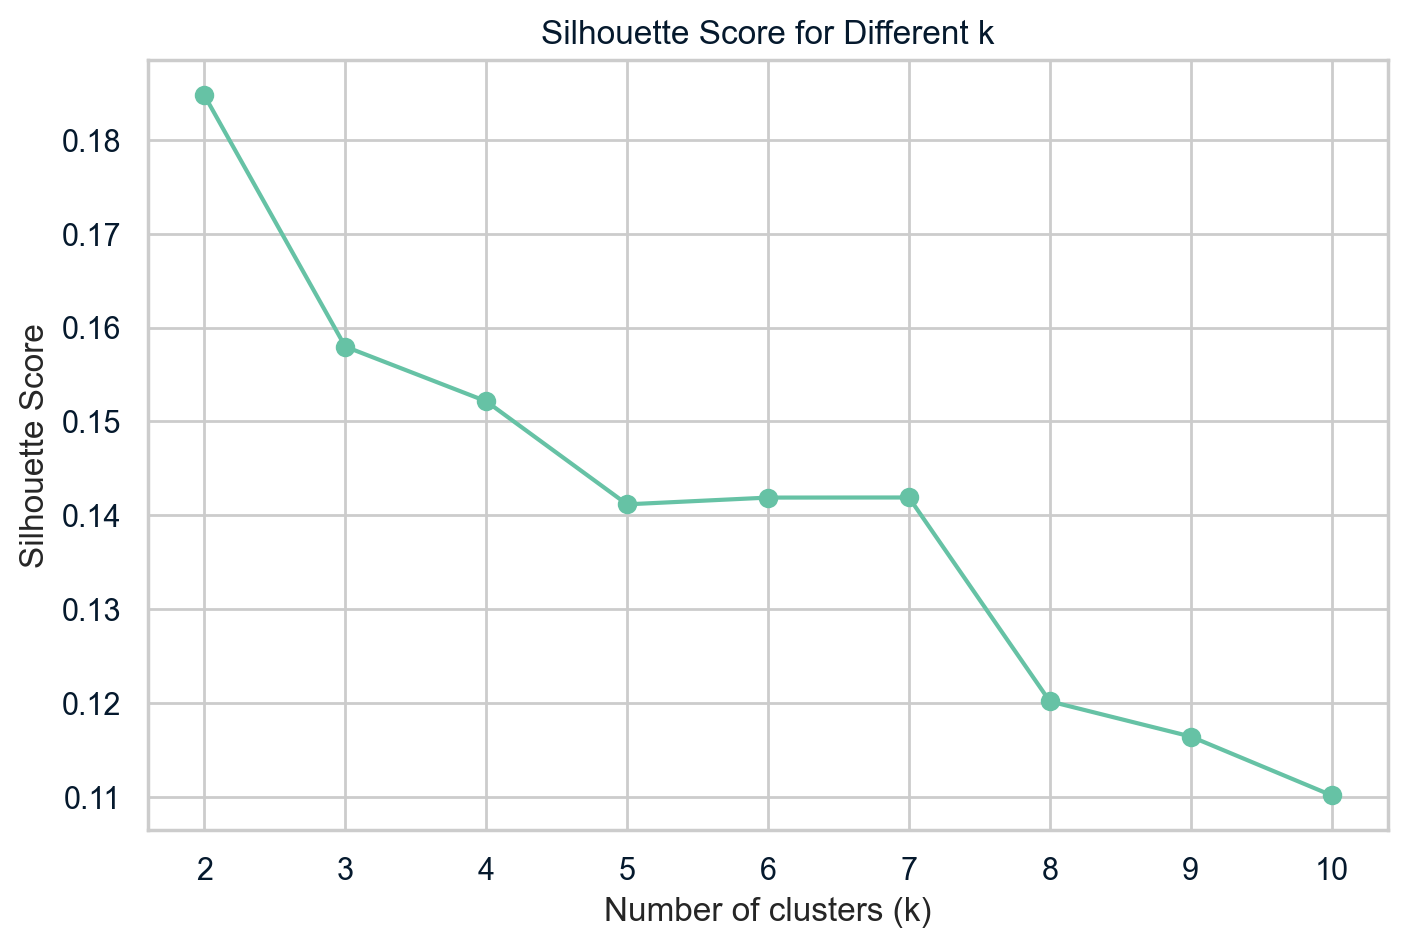

In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Separate features
numerical_features = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit']
categorical_features = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False), categorical_features)
    ]
)

# Preprocess the data
X_processed = preprocessor.fit_transform(final_patients_df)

# Find optimal k using the silhouette score
range_n_clusters = range(2, 11)
silhouette_avg = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_processed)
    silhouette_avg.append(silhouette_score(X_processed, cluster_labels))

# Plot silhouette scores to choose k
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_avg, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

Prompt: Now fit K-Means with the optimal k on the preprocessed data X. Then use PCA to reduce to 2D and plot the clusters as a scatter plot with plotly.

In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# Define features to use
numeric_features = ["Age", "BMI", "Num_Chronic_Conditions", "Annual_Visits", "Avg_Billing_Amount", "Days_Since_Last_Visit"]
categorical_features = ["Gender", "Insurance_Type", "Primary_Condition"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_features)
    ]
)

# Preprocess the data
X = preprocessor.fit_transform(final_patients_df)

# Set optimal k (replace with your optimal k value)
optimal_k = 4  # <-- Change this to your determined optimal k

# Fit KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters.astype(str)
})

# Plot with plotly
fig = px.scatter(
    plot_df, x="PC1", y="PC2", color="Cluster",
    title="K-Means Clusters (PCA-reduced to 2D)",
    labels={"Cluster": "Cluster"}
)
fig.show()

Prompt: Compute feature importance as the standard deviation of each numeric feature in num_cols across cluster centers.

K-Means is the most popular clustering algorithm. K-Means is elegant and fast. But it has a fundamental limitation: it uses Euclidean distance, which only works with numeric data.

In your case, K-Means only found 3 clusters, and the elbow method picked k=2 as "best." But does that really mean your patients only fall into 3 groups?

No, here's what went wrong:

**One-hot encoding**: Converted 3 categorical columns into ~15 binary columns, inflating dimensionality |
**Euclidean distance**: Treats every binary column equally — a 0/1 difference in "Gender_Male" weighs the same as a real numeric difference in Age
**Categorical similarity lost**: "Private" vs "Medicare" insurance are treated as completely unrelated, when they actually carry meaningful similarity structure
**Sparse high-dimensional space**: K-Means struggles in high-dimensional sparse spaces — centroids become meaningless.

We need a distance measure that handles mixed data. Gower distance (1971) was designed precisely for this problem. It computes a distance between 0 and 1 for each feature, using the appropriate method for each data type: 

- **Numeric features:** normalized Manhattan distance (range-scaled)
- **Categorical features:** simple matching (0 if same, 1 if different)
- **Final distance:** weighted average across all features

This means each feature contributes equally regardless of type, and we don't need to use one-hot encoding. 

With a proper distance matrix in hand, we can use hierarchical (agglomerative) clustering using **weighted linkage**, which works directly on a precomputed distance matrix. 

Hierarchical clustering:

- Works with any distance matrix: including our Gower distances.
- Does not require specifying the number of clusters upfront.
- Produces a dendrogram: a tree that shows how patients merge into clusters step by

Prompt: The K-Means approach didn't work well for the dataset because I have mixed numeric and categorical features. One-hot encoding inflated the dimensionality and Euclidean distance doesn't handle categories properly. Instead, use Gower distance using gower library, installed it if necessary. Use the final_patients_df DataFrame.

In [23]:
# Install gower if not already installed
import sys
import subprocess

try:
    import gower
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gower"])
    import gower

# Compute Gower distance matrix for final_patients_df
gower_dist_matrix = gower.gower_matrix(final_patients_df)


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Prompt: Now use agglomerative clustering with average linkage on the Gower distance matrix. Use the silhouette score on the precomputed distance matrix to choose the number of clusters. Set precomputed as metric hyperparameter in AgglomerativeClustering. Do not use affinity hyperparameter as it is deprecated.

In [24]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# Try different numbers of clusters and compute silhouette scores
range_n_clusters = range(2, 11)
silhouette_scores = []

for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='average',
        metric='precomputed'
    )
    cluster_labels = clusterer.fit_predict(gower_dist_matrix)
    score = silhouette_score(gower_dist_matrix, cluster_labels, metric='precomputed')
    silhouette_scores.append(score)

# Select the best number of clusters
best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]

# Fit final model with the best number of clusters
final_clusterer = AgglomerativeClustering(
    n_clusters=best_n_clusters,
    linkage='average',
    metric='precomputed'
)
final_labels = final_clusterer.fit_predict(gower_dist_matrix)

# Add cluster labels to the DataFrame
final_patients_df['Cluster'] = final_labels

Prompt: For the agglomerative clustering run above, show me a dendrogram and cluster profiles. 

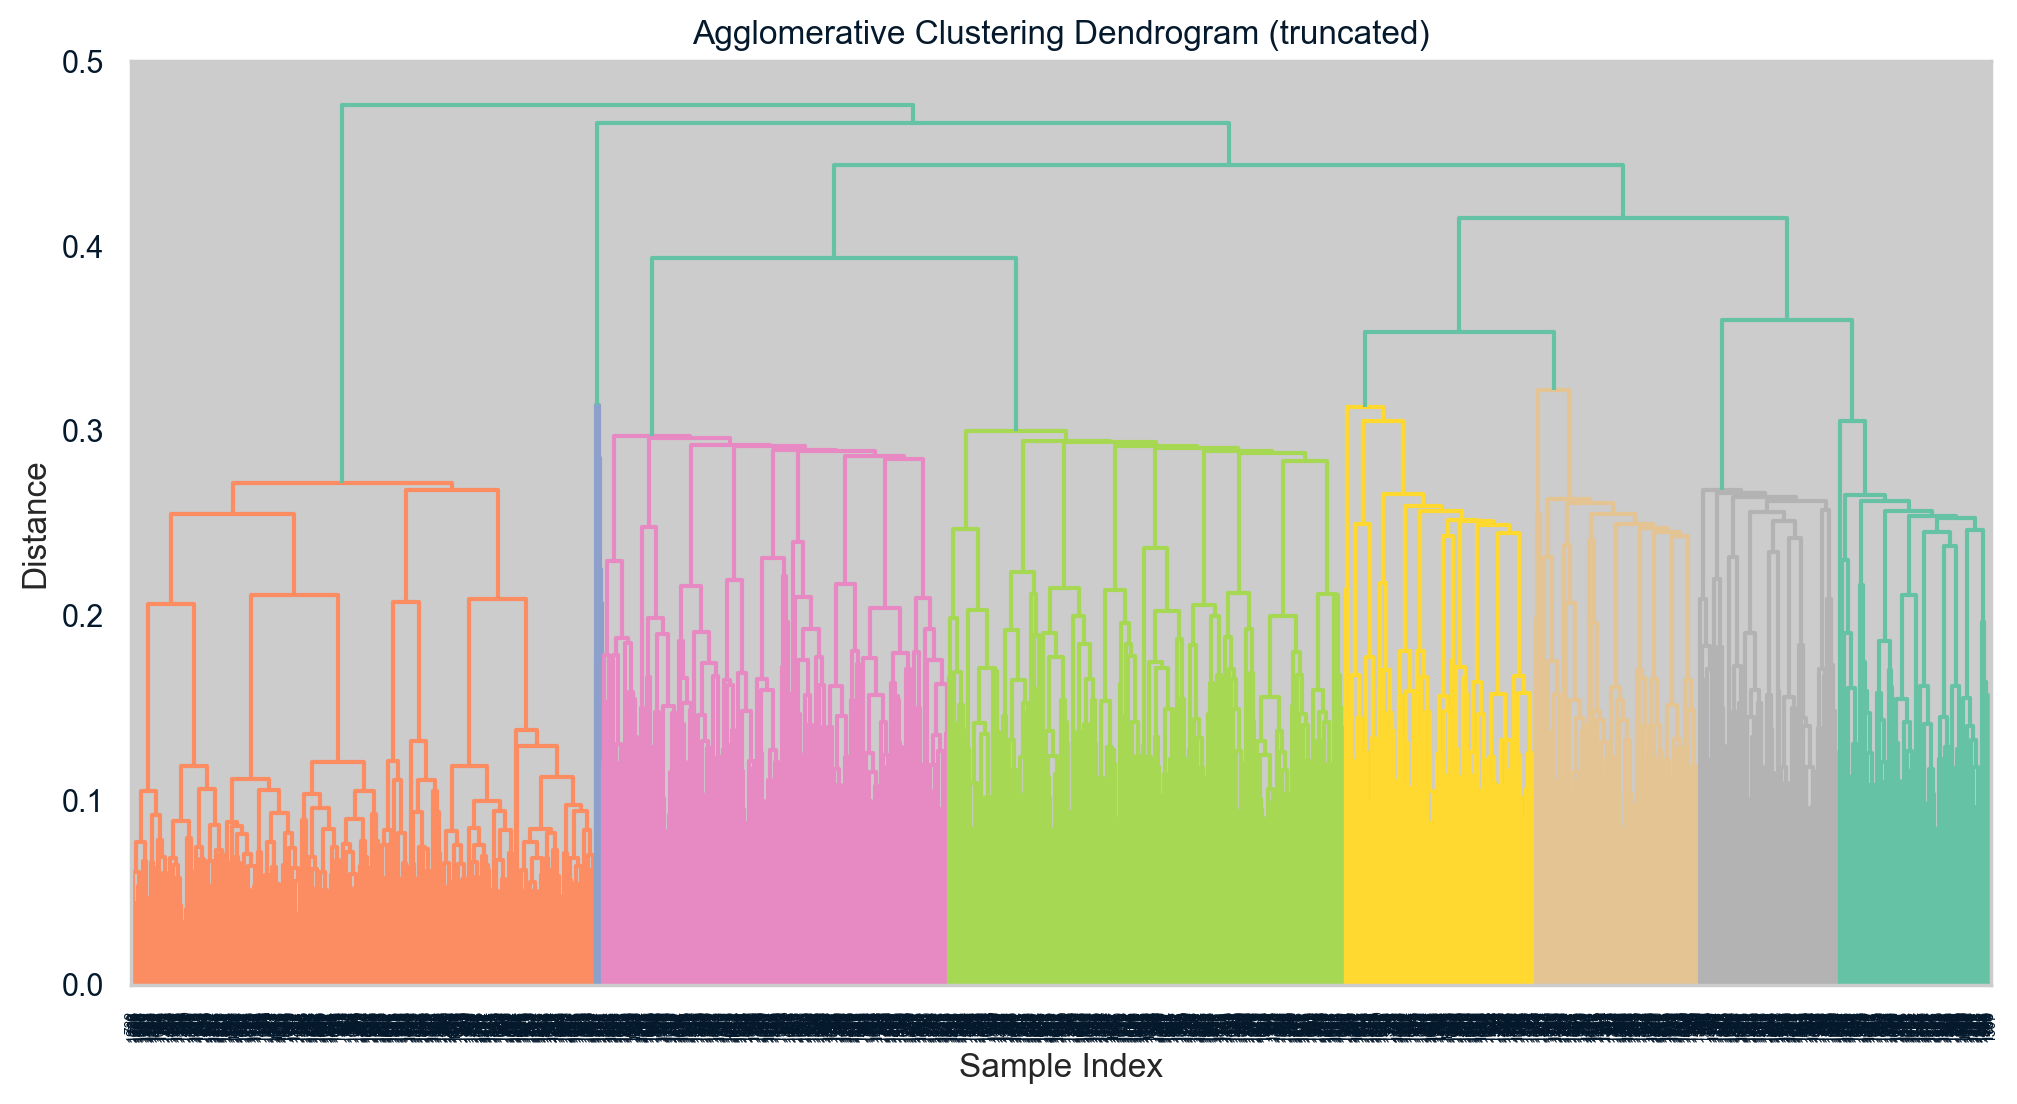

Gender,Female,Male
Cluster,,
0,0.479100,0.520900
1,0.496063,0.503937
2,0.000000,1.000000
3,0.476768,0.523232
4,1.000000,0.000000
5,0.000000,1.000000


Insurance_Type,Medicaid,Medicare,Private,Self-Pay
Cluster,,,,
0,1.000000,0.00000,0.000000,0.000000
1,0.000000,0.00000,1.000000,0.000000
2,0.250000,0.00000,0.750000,0.000000
3,0.343434,0.20404,0.319192,0.133333
4,0.000000,1.00000,0.000000,0.000000
5,0.000000,1.00000,0.000000,0.000000


Primary_Condition,Anxiety,Arthritis,Asthma,COPD,Depression,Diabetes,Heart Disease,Hypertension,No Condition,Obesity
Cluster,,,,,,,,,,
0,0.106109,0.109325,0.083601,0.112540,0.138264,0.125402,0.125402,0.112540,0.0,0.086817
1,0.110236,0.118110,0.107612,0.089239,0.110236,0.102362,0.083990,0.152231,0.0,0.125984
2,0.250000,0.000000,0.000000,0.125000,0.250000,0.000000,0.125000,0.125000,0.0,0.125000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
4,0.138173,0.110070,0.117096,0.081967,0.086651,0.100703,0.088993,0.133489,0.0,0.142857
5,0.103175,0.097884,0.113757,0.108466,0.095238,0.097884,0.105820,0.156085,0.0,0.121693


In [25]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Dendrogram ---

# Convert the Gower distance matrix to condensed form for linkage
# (AgglomerativeClustering uses a full matrix, but linkage/dendrogram need condensed)
from scipy.spatial.distance import squareform

# If gower_dist_matrix is a numpy array, ensure it's square and symmetric
# If it's a DataFrame, convert to numpy
if isinstance(gower_dist_matrix, pd.DataFrame):
    gower_dist_array = gower_dist_matrix.values
else:
    gower_dist_array = gower_dist_matrix

# Convert to condensed distance matrix
gower_dist_condensed = squareform(gower_dist_array, checks=False)

# Perform hierarchical clustering using average linkage
Z = sch.linkage(gower_dist_condensed, method='average')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendro = sch.dendrogram(Z, truncate_mode='level', p=20)
plt.title('Agglomerative Clustering Dendrogram (truncated)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# --- Cluster Profiles ---

# Select columns for profiling (numerical and categorical)
profile_cols_num = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit']
profile_cols_cat = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Numerical summaries: mean and std per cluster
cluster_profile_num = final_patients_df.groupby('Cluster')[profile_cols_num].agg(['mean', 'std'])

# Categorical summaries: value counts (proportions) per cluster
cluster_profile_cat = {}
for col in profile_cols_cat:
    cluster_profile_cat[col] = (
        final_patients_df.groupby('Cluster')[col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

# Show numerical cluster profiles
cluster_profile_num

# Show categorical cluster profiles
for col, df in cluster_profile_cat.items():
    display(pd.DataFrame(df))

The dendrogram shows how patients are merged into clusters at each step. The height of each merge represents the distance between the groups being combined. You can "cut" the tree at different heights to get different numbers of clusters.

For understanding what each cluster means, you need to look at the average numeric features and the most common categorical values per cluster to build patient profiles as it showed above.

Prompt: For the cluster_profiles DataFrame with numeric columns Age, BMI, Num_Chronic_Conditions, Annual_Visits, Avg_Billing_Amount, Days_Since_Last_Visit, create a 2x3 grid of box plots showing each numeric feature's distribution per cluster. Use the Set2 palette. Add a main title "Feature Distributions per Cluster"

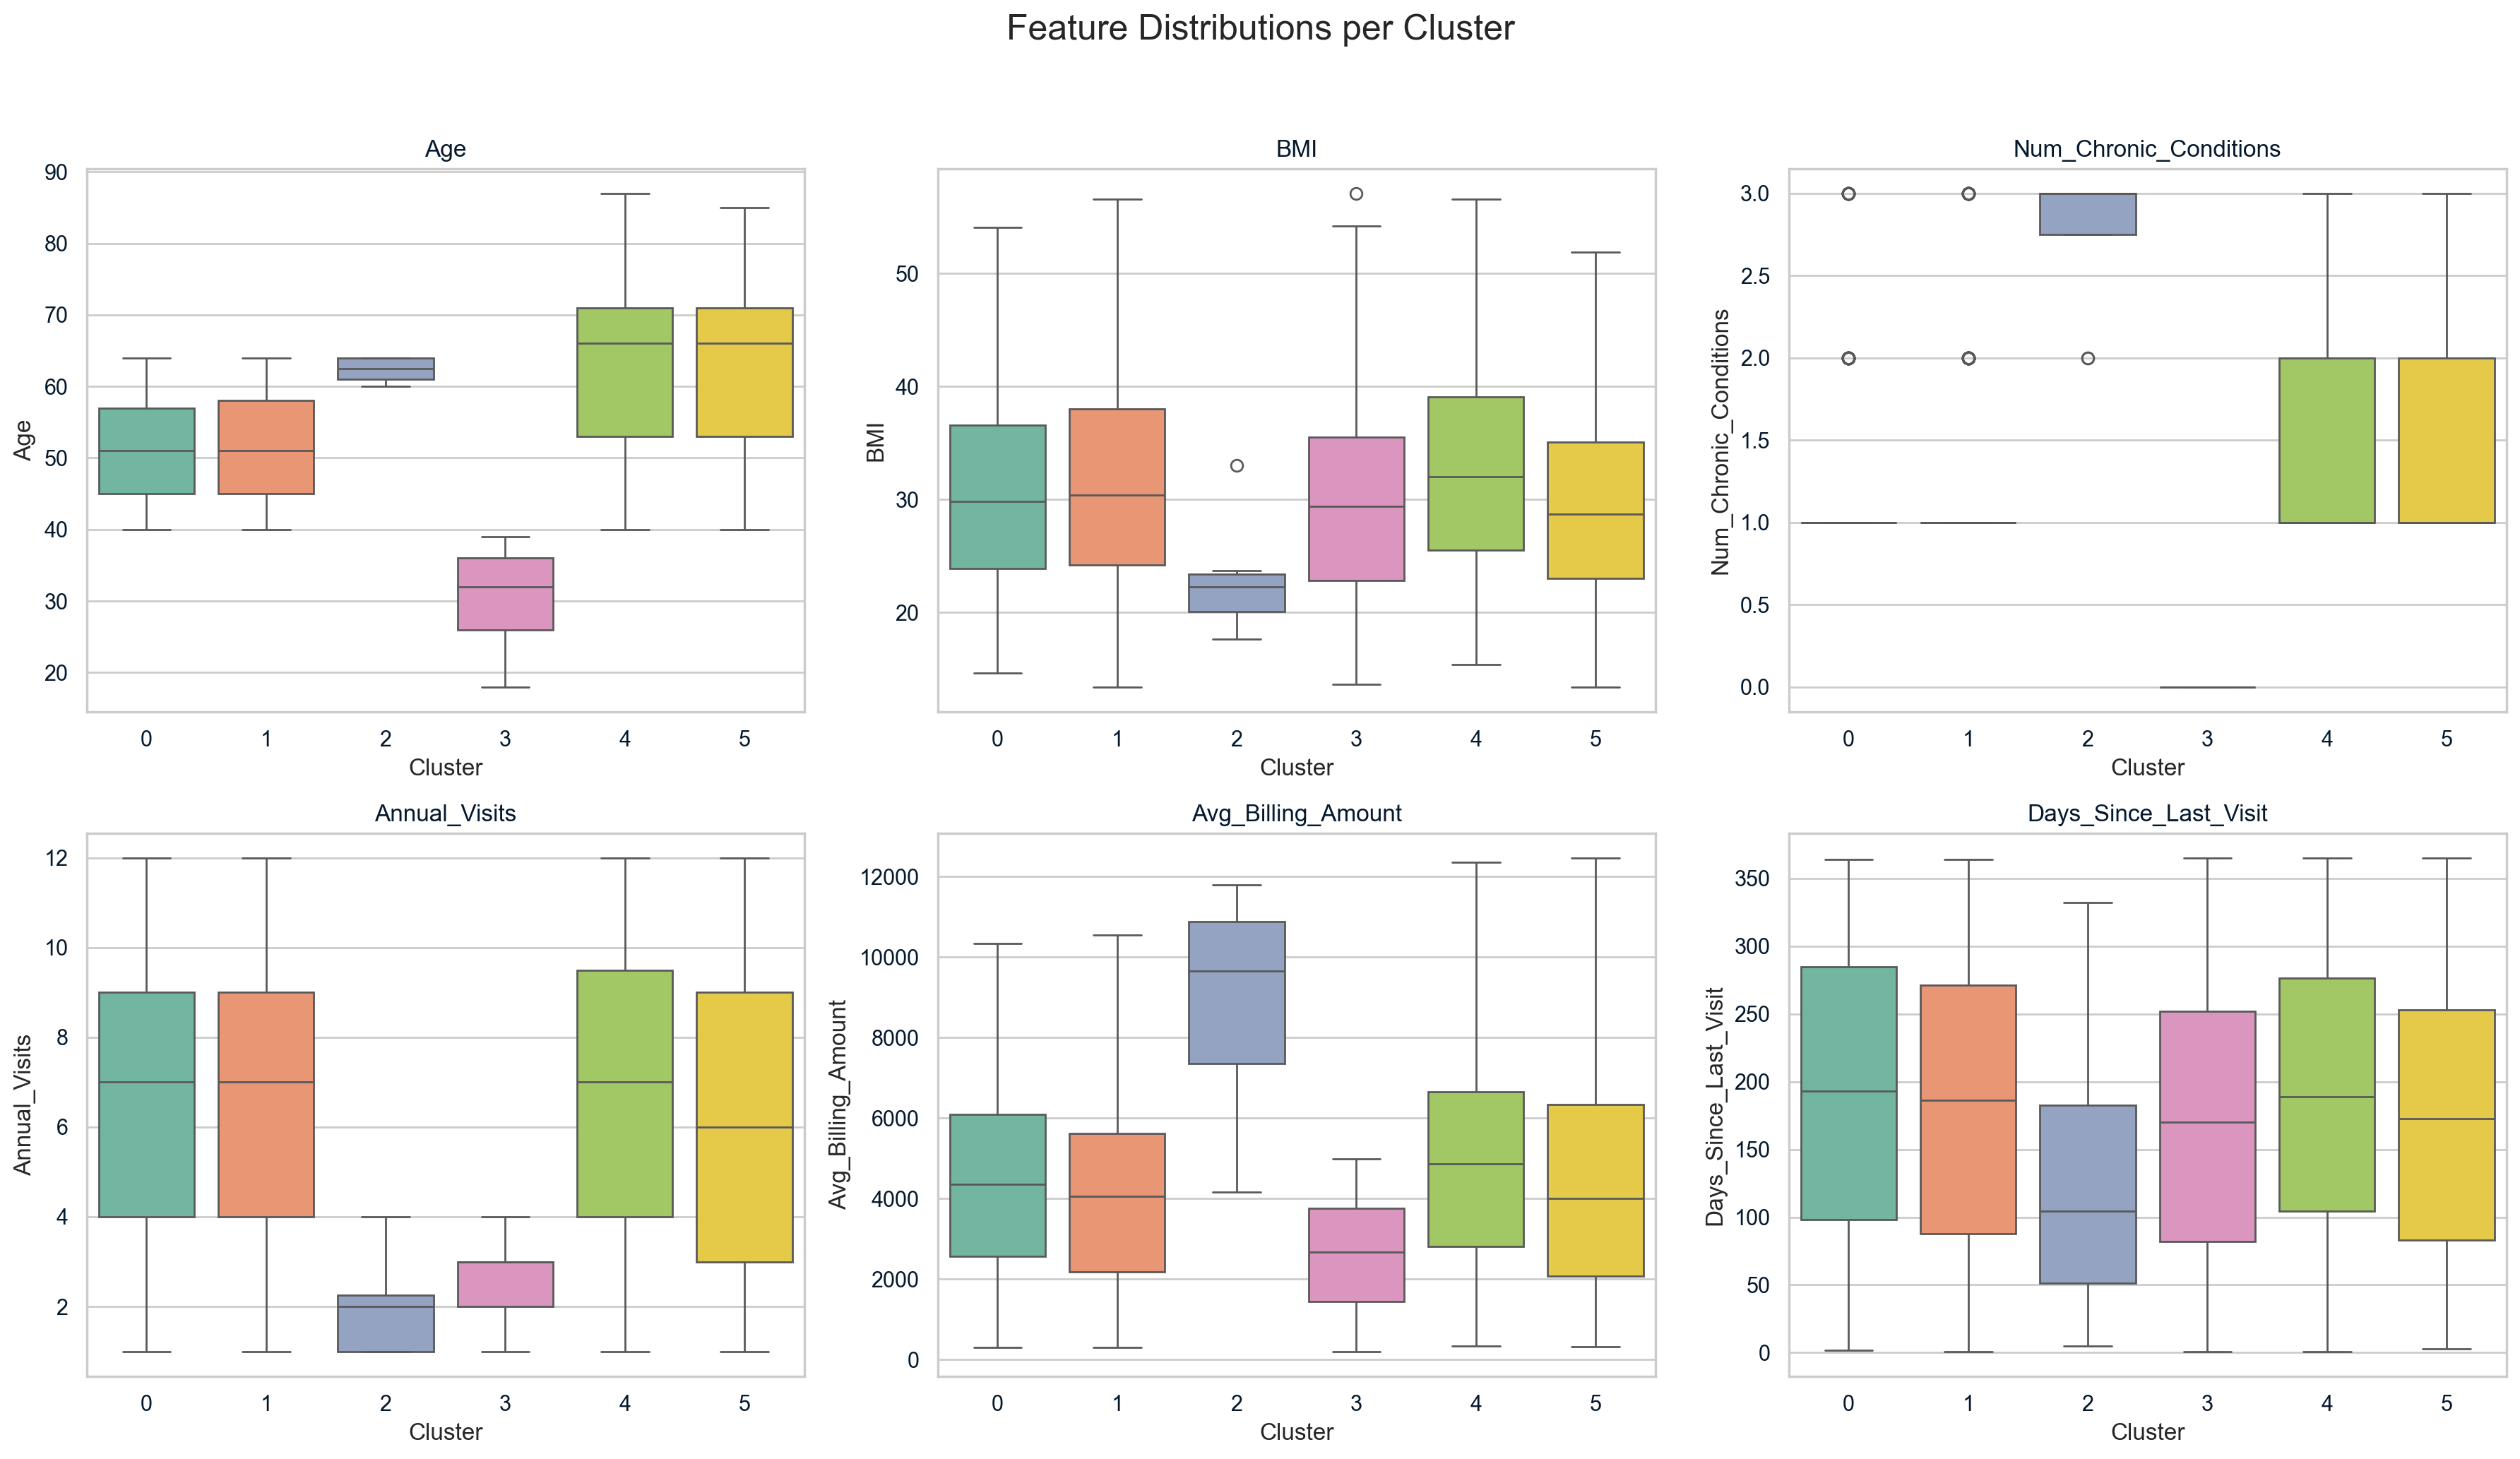

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric columns to plot
numeric_cols = [
    "Age",
    "BMI",
    "Num_Chronic_Conditions",
    "Annual_Visits",
    "Avg_Billing_Amount",
    "Days_Since_Last_Visit"
]

# Set up the matplotlib figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Use Set2 palette
palette = sns.color_palette("Set2")

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=final_patients_df,
        x="Cluster",
        y=col,
        ax=axes[i],
        palette=palette
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(col)

fig.suptitle("Feature Distributions per Cluster", fontsize=18, y=1.03)
plt.tight_layout()

## 6. Patient Segment Narratives

Based on the cluster profiles above, here are the patient segments you discovered. Let's generate a clear summary for each cluster that a non-technical stakeholder could understand: this is what makes clustering actionable.

Prompt: For each Cluster in my patient DataFrame, generate a narrative summary. For each cluster show: the number of patients and percentage of total, the mean of each numeric column (Age, BMI, Num_Chronic_Conditions, Annual_Visits, Avg_Billing_Amount, Days_Since_Last_Visit), and the most common value (mode) of each categorical column (Gender, Insurance_Type, Primary_Condition). Format each cluster as a markdown table with an interpretive heading. Use display(Markdown()) to render it.

In [27]:
from IPython.display import display, Markdown
import pandas as pd

# Columns to summarize
numeric_cols = ["Age", "BMI", "Num_Chronic_Conditions", "Annual_Visits", "Avg_Billing_Amount", "Days_Since_Last_Visit"]
categorical_cols = ["Gender", "Insurance_Type", "Primary_Condition"]

total_patients = len(final_patients_df)
cluster_labels = sorted(final_patients_df['Cluster'].unique())

for cluster in cluster_labels:
    cluster_df = final_patients_df[final_patients_df['Cluster'] == cluster]
    n_patients = len(cluster_df)
    pct_patients = n_patients / total_patients * 100

    # Calculate means for numeric columns
    means = cluster_df[numeric_cols].mean().round(2)

    # Calculate modes for categorical columns
    modes = {}
    for col in categorical_cols:
        mode_val = cluster_df[col].mode()
        if not mode_val.empty:
            modes[col] = mode_val.iloc[0]
        else:
            modes[col] = "N/A"

    # Build markdown table
    md = f"### Cluster {cluster}: {n_patients} patients ({pct_patients:.1f}% of total)\n\n"
    md += "| Feature | Value |\n"
    md += "|---|---|\n"
    md += f"| **Number of Patients** | {n_patients} |\n"
    md += f"| **Percentage of Total** | {pct_patients:.1f}% |\n"
    for col in numeric_cols:
        md += f"| **Mean {col.replace('_', ' ')}** | {means[col]} |\n"
    for col in categorical_cols:
        md += f"| **Most Common {col.replace('_', ' ')}** | {modes[col]} |\n"

    # Add a brief interpretive heading
    md = f"## Patient Segment: Cluster {cluster}\n\n" + md

    display(Markdown(md))

## Patient Segment: Cluster 0

### Cluster 0: 311 patients (15.6% of total)

| Feature | Value |
|---|---|
| **Number of Patients** | 311 |
| **Percentage of Total** | 15.6% |
| **Mean Age** | 51.07 |
| **Mean BMI** | 30.54 |
| **Mean Num Chronic Conditions** | 1.15 |
| **Mean Annual Visits** | 6.5 |
| **Mean Avg Billing Amount** | 4317.77 |
| **Mean Days Since Last Visit** | 188.4 |
| **Most Common Gender** | Male |
| **Most Common Insurance Type** | Medicaid |
| **Most Common Primary Condition** | Depression |


## Patient Segment: Cluster 1

### Cluster 1: 381 patients (19.1% of total)

| Feature | Value |
|---|---|
| **Number of Patients** | 381 |
| **Percentage of Total** | 19.1% |
| **Mean Age** | 51.58 |
| **Mean BMI** | 31.41 |
| **Mean Num Chronic Conditions** | 1.17 |
| **Mean Annual Visits** | 6.68 |
| **Mean Avg Billing Amount** | 3956.6 |
| **Mean Days Since Last Visit** | 182.33 |
| **Most Common Gender** | Male |
| **Most Common Insurance Type** | Private |
| **Most Common Primary Condition** | Hypertension |


## Patient Segment: Cluster 2

### Cluster 2: 8 patients (0.4% of total)

| Feature | Value |
|---|---|
| **Number of Patients** | 8 |
| **Percentage of Total** | 0.4% |
| **Mean Age** | 62.38 |
| **Mean BMI** | 22.69 |
| **Mean Num Chronic Conditions** | 2.75 |
| **Mean Annual Visits** | 2.0 |
| **Mean Avg Billing Amount** | 8884.81 |
| **Mean Days Since Last Visit** | 131.12 |
| **Most Common Gender** | Male |
| **Most Common Insurance Type** | Private |
| **Most Common Primary Condition** | Anxiety |


## Patient Segment: Cluster 3

### Cluster 3: 495 patients (24.8% of total)

| Feature | Value |
|---|---|
| **Number of Patients** | 495 |
| **Percentage of Total** | 24.8% |
| **Mean Age** | 30.4 |
| **Mean BMI** | 29.89 |
| **Mean Num Chronic Conditions** | 0.0 |
| **Mean Annual Visits** | 2.51 |
| **Mean Avg Billing Amount** | 2598.31 |
| **Mean Days Since Last Visit** | 173.49 |
| **Most Common Gender** | Male |
| **Most Common Insurance Type** | Medicaid |
| **Most Common Primary Condition** | No Condition |


## Patient Segment: Cluster 4

### Cluster 4: 427 patients (21.3% of total)

| Feature | Value |
|---|---|
| **Number of Patients** | 427 |
| **Percentage of Total** | 21.3% |
| **Mean Age** | 62.58 |
| **Mean BMI** | 32.65 |
| **Mean Num Chronic Conditions** | 1.66 |
| **Mean Annual Visits** | 6.63 |
| **Mean Avg Billing Amount** | 4932.63 |
| **Mean Days Since Last Visit** | 186.64 |
| **Most Common Gender** | Female |
| **Most Common Insurance Type** | Medicare |
| **Most Common Primary Condition** | Obesity |


## Patient Segment: Cluster 5

### Cluster 5: 378 patients (18.9% of total)

| Feature | Value |
|---|---|
| **Number of Patients** | 378 |
| **Percentage of Total** | 18.9% |
| **Mean Age** | 62.4 |
| **Mean BMI** | 29.36 |
| **Mean Num Chronic Conditions** | 1.66 |
| **Mean Annual Visits** | 6.03 |
| **Mean Avg Billing Amount** | 4462.37 |
| **Mean Days Since Last Visit** | 173.24 |
| **Most Common Gender** | Male |
| **Most Common Insurance Type** | Medicare |
| **Most Common Primary Condition** | Hypertension |


## 7. Predicting the Segment for a New Patient

The clustering is done and our segments are defined. But here's a real-world question: **what happens when a new patient enrolls tomorrow?** 

You need to be able to assign them to the right segment without re-running the entire clustering.

The idea is simple: compute the Gower distance from the new patient to every existing patient, then see which cluster they're closest to on average.

Prompt: I want to predict which cluster a brand-new patient belongs to. Write a function that takes a dictionary of the new patient's features, the original DataFrame, the Gower distance matrix, and the numeric/categorical column lists. For each existing patient, compute the Gower distance to the new patient the same way we did before. Then compute the average distance from the new patient to each cluster. Return the closest cluster and the distances to all clusters. Test it with a sample patient: 55-year-old female, Medicare, Hypertension, BMI 32, 2 chronic conditions, 6 annual visits, $3,500 avg billing, 120 days since last visit.

In [28]:
import numpy as np
import pandas as pd

def gower_distance_row(row1, row2, numeric_cols, categorical_cols):
    """
    Compute Gower distance between two rows (Series or dicts).
    """
    num_dist = 0
    num_count = 0
    for col in numeric_cols:
        rng = row1[col].max() - row1[col].min() if hasattr(row1[col], 'max') else None
        # If range is not provided, compute from both rows
        if rng is None or rng == 0:
            rng = max(row1[col], row2[col]) - min(row1[col], row2[col])
        if rng == 0:
            d = 0
        else:
            d = abs(row1[col] - row2[col]) / rng
        num_dist += d
        num_count += 1
    cat_dist = 0
    cat_count = 0
    for col in categorical_cols:
        d = 0 if row1[col] == row2[col] else 1
        cat_dist += d
        cat_count += 1
    total = 0
    denom = 0
    if num_count > 0:
        total += num_dist
        denom += num_count
    if cat_count > 0:
        total += cat_dist
        denom += cat_count
    return total / denom if denom > 0 else 0

def gower_distance_to_new_patient(new_patient_dict, df, numeric_cols, categorical_cols):
    """
    Compute Gower distance from new patient to each row in df.
    """
    # For numeric columns, get min/max for scaling
    mins = df[numeric_cols].min()
    maxs = df[numeric_cols].max()
    ranges = maxs - mins
    # Build a DataFrame with the new patient repeated
    new_patient_df = pd.DataFrame([new_patient_dict]*len(df), columns=df.columns)
    # Numeric part
    num_dists = np.abs(df[numeric_cols].values - new_patient_df[numeric_cols].values) / ranges.values
    num_dists = np.nan_to_num(num_dists)  # handle division by zero
    # Categorical part
    cat_dists = (df[categorical_cols].values != new_patient_df[categorical_cols].values).astype(float)
    # Combine
    total_dists = np.hstack([num_dists, cat_dists])
    gower_dists = total_dists.mean(axis=1)
    return gower_dists

def predict_new_patient_cluster(new_patient_dict, df, numeric_cols, categorical_cols, cluster_col='Cluster'):
    """
    Predict the cluster for a new patient.
    Returns: (closest_cluster, cluster_distances_dict)
    """
    # Compute Gower distances to all patients
    dists = gower_distance_to_new_patient(new_patient_dict, df, numeric_cols, categorical_cols)
    df_with_dists = df.copy()
    df_with_dists['gower_dist'] = dists
    # Compute average distance to each cluster
    cluster_distances = df_with_dists.groupby(cluster_col)['gower_dist'].mean().to_dict()
    # Find closest cluster
    closest_cluster = min(cluster_distances, key=cluster_distances.get)
    return closest_cluster, cluster_distances

# Define columns
numeric_cols = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit']
categorical_cols = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Sample patient
sample_patient = {
    'Age': 55,
    'BMI': 32,
    'Num_Chronic_Conditions': 2,
    'Annual_Visits': 6,
    'Avg_Billing_Amount': 3500.0,
    'Days_Since_Last_Visit': 120,
    'Gender': 'Female',
    'Insurance_Type': 'Medicare',
    'Primary_Condition': 'Hypertension'
}

# Predict cluster for sample patient
closest_cluster, cluster_distances = predict_new_patient_cluster(
    sample_patient,
    final_patients_df,
    numeric_cols,
    categorical_cols,
    cluster_col='Cluster'
)

# Output: closest_cluster, cluster_distances
closest_cluster, cluster_distances

(4,
 {0: 0.4122696343645364,
  1: 0.40446264636037593,
  2: 0.499439648941796,
  3: 0.467214616167506,
  4: 0.2481962804576177,
  5: 0.35201719962384437})

## Key Takeaways 

1. **Always explore your data first** — distributions, missing values, and correlations tell you what preprocessing is needed.

2. **AI-assisted coding accelerates your workflow** but your domain knowledge is irreplaceable. You need to validate and sometimes correct the AI.

3. **Algorithm choice matters**: K-Means with one-hot encoding failed because Euclidean distance doesn't handle mixed data well. Gower distance was the right tool for this dataset.

4. **Clustering is only useful if you can interpret it**: the real value is in the patient segment narratives that inform clinical and business decisions.

5. **Practice!**: The best way to learn is by doing.